<a href="https://colab.research.google.com/github/fadeeva/portfoli_o_o_ptimisation/blob/main/Step_01__Basics_Return_Risk_Correlation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

import datetime as dt
import yfinance as yf

import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [2]:
rng = np.random.default_rng(42)

# Basics: Return, Risk, Correlation

In [3]:
tickers  = ['AMD', 'AMZN', 'BAC', 'META', 'AVGO', 'TER', 'NVDA']

df = yf.download(tickers, dt.datetime(2022, 1, 1), dt.datetime.now(), auto_adjust=True)
df = df['Close']

df.head()

[*********************100%***********************]  7 of 7 completed


Ticker,AMD,AMZN,AVGO,BAC,META,NVDA,TER
Date,,,,,,,
2022-01-03,150.240005,170.404495,61.316093,41.265347,335.592987,30.026148,163.144073
2022-01-04,144.419998,167.522003,62.018616,42.882721,333.600403,29.197763,163.409271
2022-01-05,136.149994,164.356995,59.437752,42.158916,321.348083,27.517069,157.388718
2022-01-06,136.229996,163.253998,58.885887,43.007812,329.565887,28.089262,160.561035
2022-01-07,132.000000,162.554001,57.233105,43.946072,328.901764,27.161192,155.444077


## Log Return and Simple Return

**Cummulative Returns**

(1+simple_return).cumprod()

exp(log_return.cumsum()) - 1

In [4]:
df_res = pd.concat([df, df.pct_change().add_suffix('_simp_ret')], axis=1)
df_res = pd.concat([df_res, np.log(df / df.shift(1)).add_suffix('_log_ret')], axis=1)
df_res.dropna(inplace=True)
df_res.head()

Ticker,AMD,AMZN,AVGO,BAC,META,NVDA,TER,AMD_simp_ret,AMZN_simp_ret,AVGO_simp_ret,...,META_simp_ret,NVDA_simp_ret,TER_simp_ret,AMD_log_ret,AMZN_log_ret,AVGO_log_ret,BAC_log_ret,META_log_ret,NVDA_log_ret,TER_log_ret
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-04,144.419998,167.522003,62.018616,42.882721,333.600403,29.197763,163.409271,-0.038738,-0.016916,0.011457,...,-0.005938,-0.027589,0.001626,-0.039508,-0.017060,0.011392,0.038446,-0.005955,-0.027976,0.001624
2022-01-05,136.149994,164.356995,59.437752,42.158916,321.348083,27.517069,157.388718,-0.057264,-0.018893,-0.041614,...,-0.036728,-0.057562,-0.036843,-0.058969,-0.019074,-0.042505,-0.017023,-0.037419,-0.059286,-0.037539
2022-01-06,136.229996,163.253998,58.885887,43.007812,329.565887,28.089262,160.561035,0.000588,-0.006711,-0.009285,...,0.025573,0.020794,0.020156,0.000587,-0.006734,-0.009328,0.019936,0.025251,0.020581,0.019955
2022-01-07,132.000000,162.554001,57.233105,43.946072,328.901764,27.161192,155.444077,-0.031050,-0.004288,-0.028068,...,-0.002015,-0.033040,-0.031869,-0.031543,-0.004297,-0.028469,0.021581,-0.002017,-0.033598,-0.032388
2022-01-10,132.000000,161.485992,57.418900,43.722687,325.214111,27.313715,153.813705,0.000000,-0.006570,0.003246,...,-0.011212,0.005615,-0.010488,0.000000,-0.006592,0.003241,-0.005096,-0.011275,0.005600,-0.010544


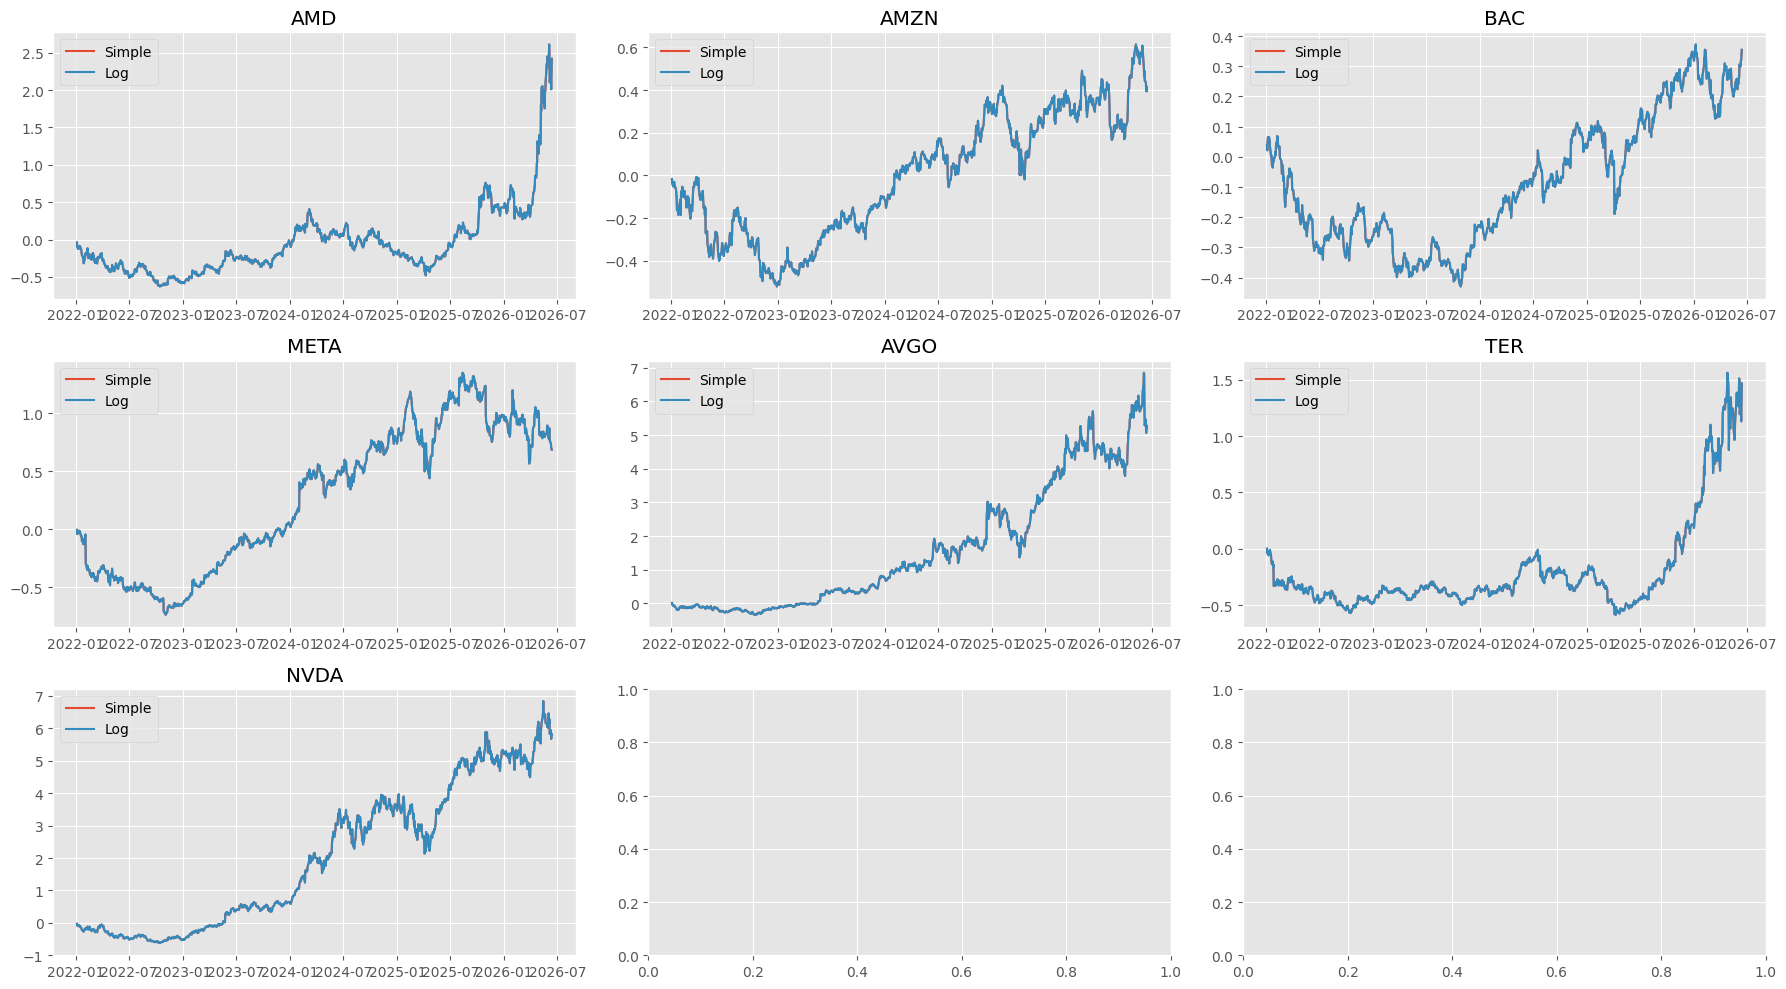

In [ ]:
fig, axs = plt.subplots(3, 3, figsize=(18, 10))
axs = axs.flatten()

for i, ticker in enumerate(tickers):
    axs[i].plot((1 + df_res[f'{ticker}_simp_ret']).cumprod() - 1, label='Simple')
    axs[i].plot(np.exp(df_res[f'{ticker}_log_ret'].cumsum()) - 1, label='Log')
    axs[i].set_title(f'{ticker}')
    axs[i].legend()

plt.tight_layout();

## Correlation and Covariation

Prices are **not stationary** (they have a trend), so any two prices will correlate simply due to general market growth/inflation

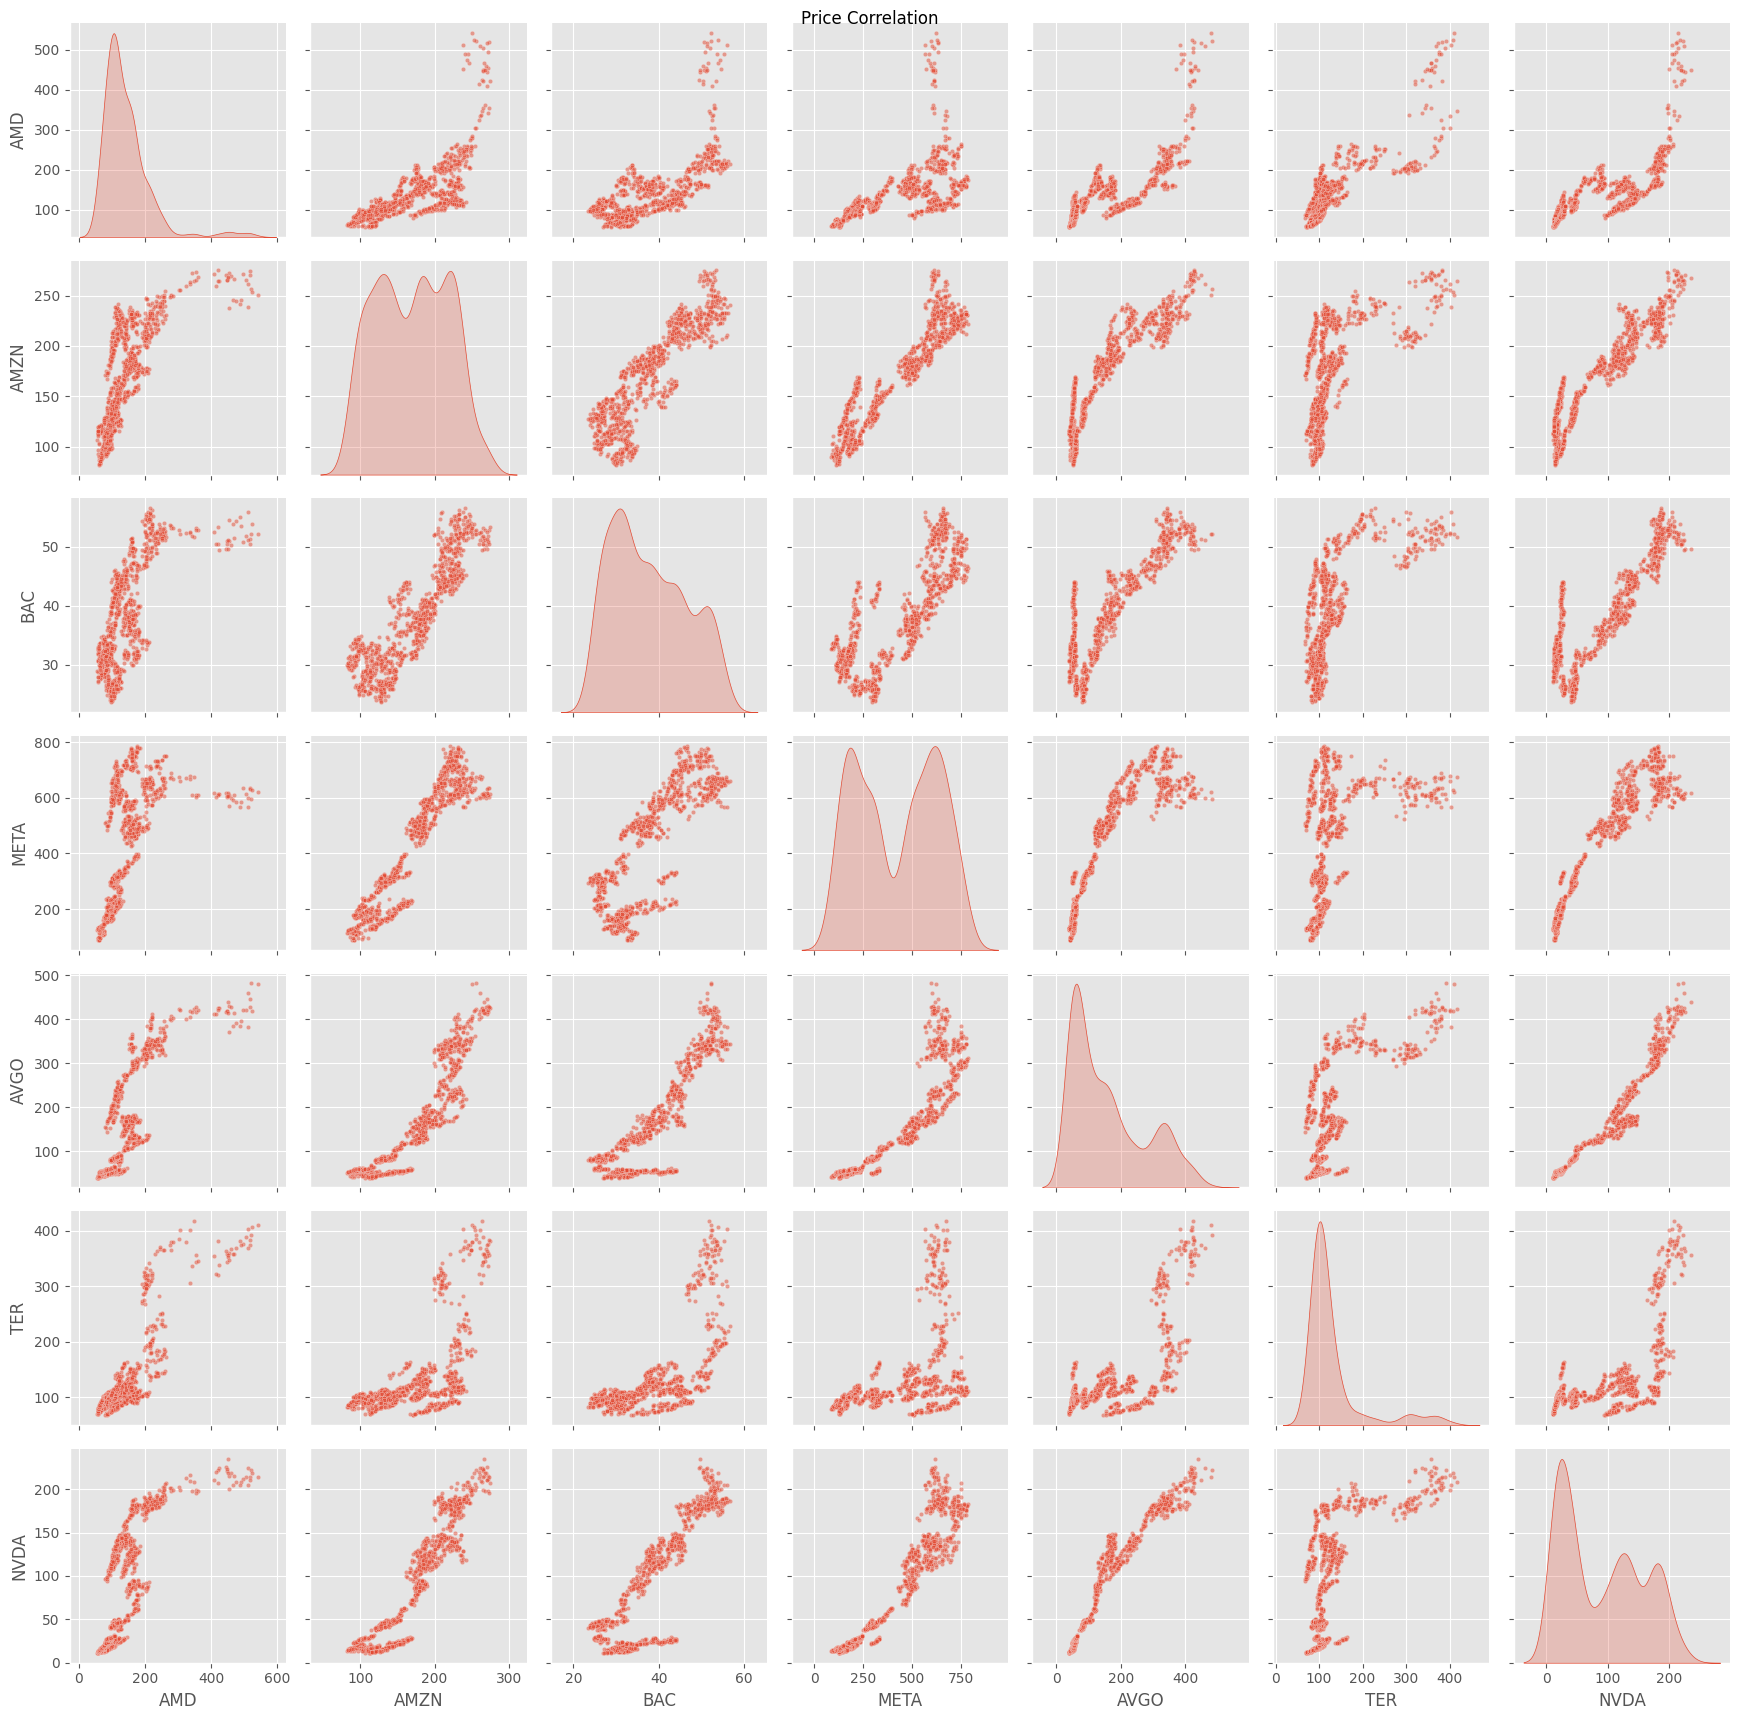

In [ ]:
pp = sns.pairplot(
    df_res[tickers],
    diag_kind='kde', kind='scatter',
    plot_kws={'alpha': 0.5, 's': 10}, diag_kws={'fill': True})

pp.figure.suptitle('Price Correlation')
plt.tight_layout()

Text(0.5, 1.0, 'Price Correlations')

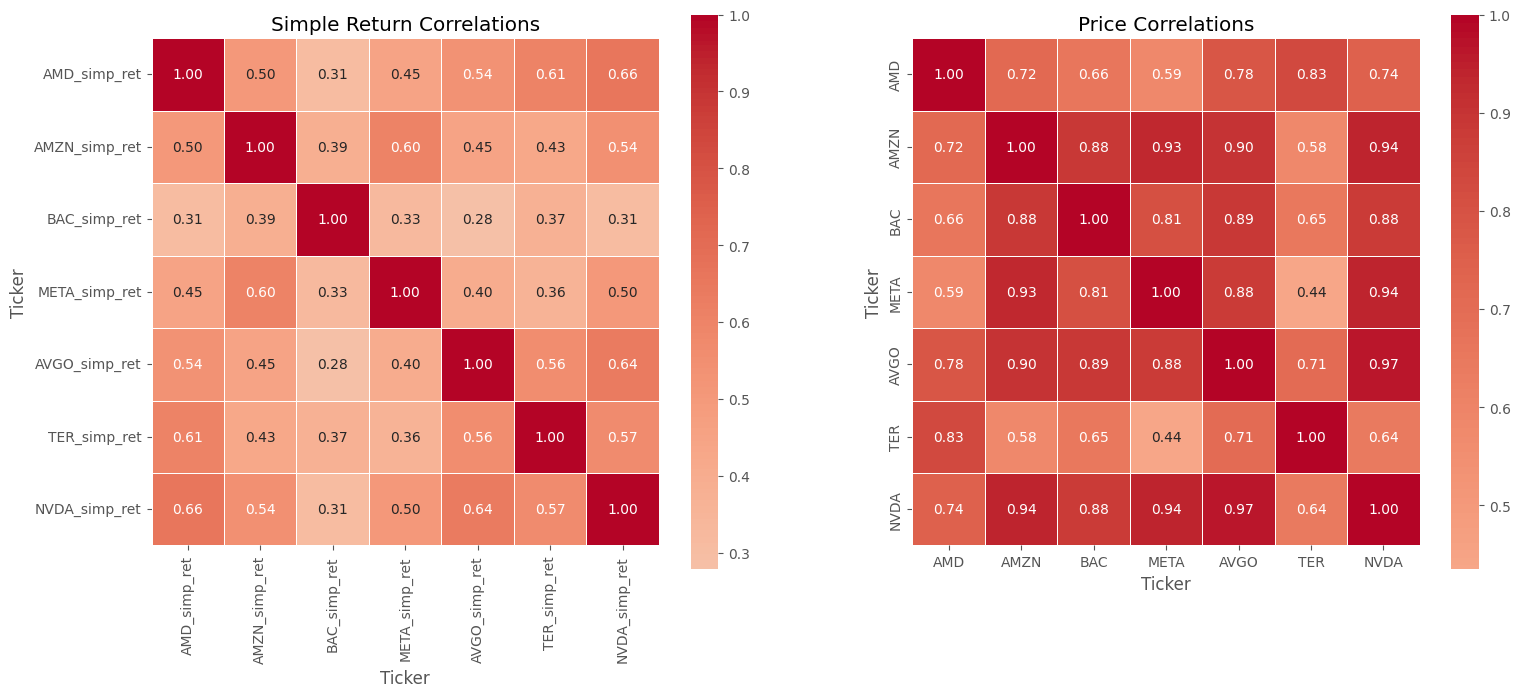

In [ ]:
corr_matrix_simp_ret = df_res[[ticker+'_simp_ret' for ticker in tickers]].corr()
corr_matrix_log_ret = df_res[[ticker+'_log_ret' for ticker in tickers]].corr()

fig, axs = plt.subplots(1, 2, figsize=(18, 9))
sns.heatmap(corr_matrix_simp_ret,
            annot=True,
            cmap='coolwarm', center=0,
            fmt='.2f', square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=axs[0])\
    .set_title('Simple Return Correlations')
sns.heatmap(df[tickers].corr(),
            annot=True,
            cmap='coolwarm', center=0,
            fmt='.2f', square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=axs[1])\
    .set_title('Price Correlations')

Text(0.5, 1.0, 'Logarithmic Return Covariance Matrix')

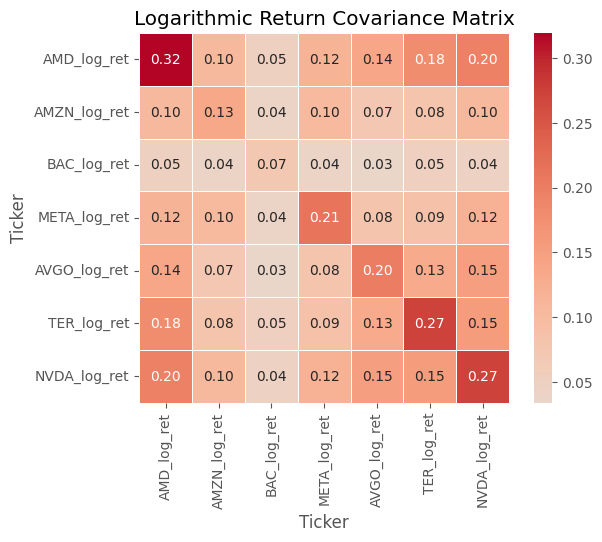

In [ ]:
cov_matrix = df_res[[f'{ticker}_log_ret' for ticker in tickers]].cov() * 252

sns.heatmap(
    cov_matrix,
    annot=True,
    cmap='coolwarm', center=0,
    fmt='.2f', square=True,
    linewidths=0.5)\
    .set_title('Logarithmic Return Covariance Matrix')

Text(0.5, 1.0, 'the Difference between Return Correlations and Price Correlations')

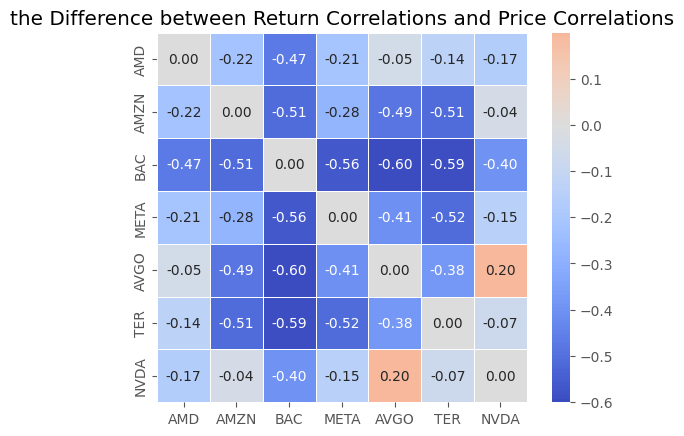

In [ ]:
diff = pd.DataFrame(
    data=corr_matrix_simp_ret.to_numpy() - df.corr().to_numpy(),
    index=tickers, columns=tickers
)

sns.heatmap(
    diff,
    annot=True,
    cmap='coolwarm', center=0,
    fmt='.2f', square=True,
    linewidths=0.5)\
    .set_title('the Difference between Return Correlations and Price Correlations')



## Annual Return and Volatility

In [5]:
years = len(df_res) / 252
total_return = df[tickers].iloc[-1] / df[tickers].iloc[0] - 1 # can't use df_res because there no first prices (dropna)

cagr = (1 + total_return) ** (1 / years) - 1
# cagr.sort_values(ascending=False, inplace=True)

annual_vol_log = df_res[[ticker+'_log_ret' for ticker in tickers]].std() * np.sqrt(252)
annual_vol_log.index = tickers
# annual_vol_log.sort_values(ascending=False, inplace=True)

# risk free rate
rf_annual = .02
rf_daily = (1 + rf_annual) ** (1/252) - 1

# excess return
excess_returns = df_res[[f'{ticker}_log_ret' for ticker in tickers]].subtract(rf_daily)
excess_returns.columns = tickers
# annual excess return
annual_excess_return = excess_returns.mean() * 252

sharpe_ratio = annual_excess_return / annual_vol_log
# sharpe_ratio.sort_values(ascending=False, inplace=True)


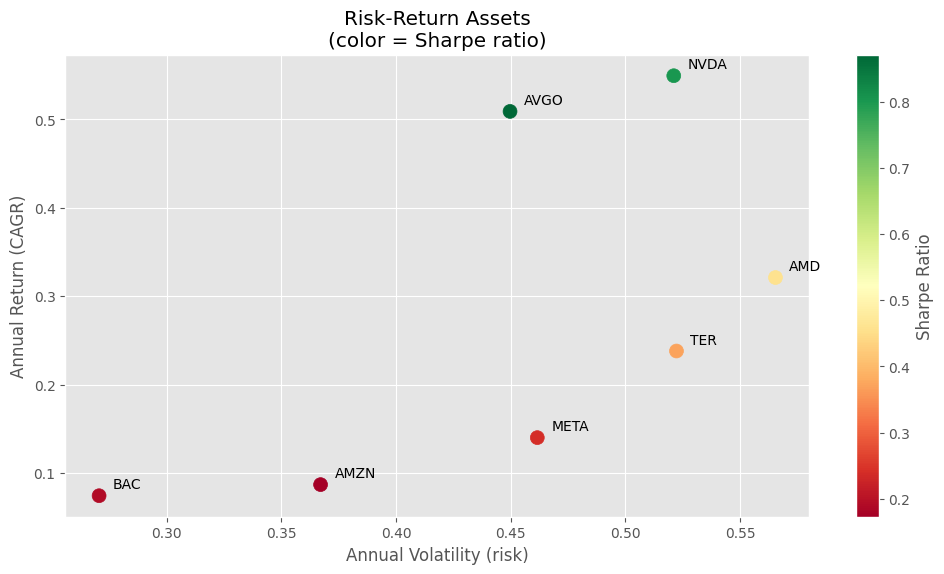

In [38]:
plt.figure(figsize=(12, 6))

scatter = plt.scatter(annual_vol_log, cagr, c=sharpe_ratio, s=100, cmap='RdYlGn')

for i, ticker in enumerate(tickers):
    plt.annotate(
        ticker,
        (annual_vol_log.iloc[i], cagr.iloc[i]),
        xytext=(10, 5), textcoords='offset points',
        fontsize=10
    )

plt.xlabel('Annual Volatility (risk)')
plt.ylabel('Annual Return (CAGR)')
plt.title('Risk-Return Assets\n(color = Sharpe ratio)')

cbar = plt.colorbar(scatter)
cbar.set_label('Sharpe Ratio')

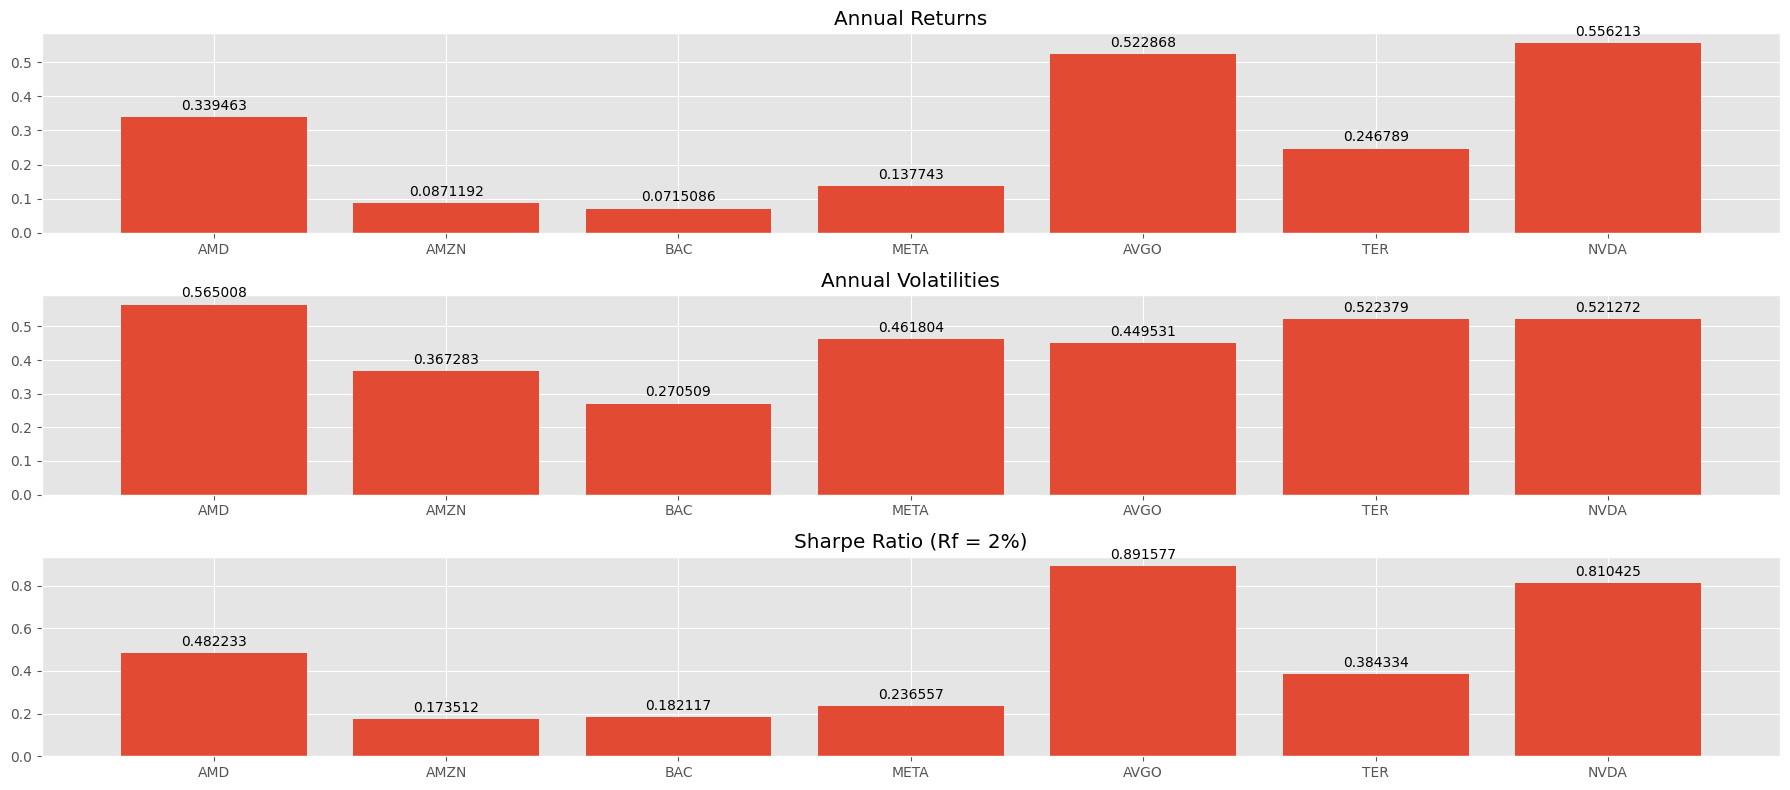

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(18, 8))

bars = axs[0].bar(cagr.index, cagr)
axs[0].bar_label(bars, padding=3)
axs[0].set_title('Annual Returns')

bars = axs[1].bar(annual_vol_log.index, annual_vol_log)
axs[1].bar_label(bars, padding=3)
axs[1].set_title('Annual Volatilities')

bars = axs[2].bar(sharpe_ratio.index, sharpe_ratio)
axs[2].bar_label(bars, padding=3);
axs[2].set_title('Sharpe Ratio (Rf = 2%)')

plt.tight_layout()